In [11]:
import pandas as pd
from scipy.stats import bootstrap

from matplotlib import pyplot as plt
import numpy as np


In [12]:
Heisenberg_ground_states = {"5": -8.472135954999581,
                            "6": -11.21110255092798,
                            "7": -12.420717027386775,
                            "8": -14.604373635748704,
                            "9": -16.189199135748044,
                            }

In [13]:

def mean_confidence_interval(data, confidence):
    res = bootstrap(
        data=(data,),
        statistic=np.mean,             
        method="BCa",                  
        confidence_level = confidence,
        n_resamples=10000
    )

    ci_low, ci_high = res.confidence_interval.low, res.confidence_interval.high

    mean = data.mean()

    return mean, ci_low, ci_high


def compute_mean_and_confidence(df, runs, confidence):
    means = []
    lower_bounds = []
    upper_bounds = []

    for i, row in df.iterrows():
        mean, lower_bound, upper_bound = mean_confidence_interval(data = row[:runs], confidence = confidence)
        
        means.append(mean)
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)

    return np.array(means), np.array(lower_bounds), np.array(upper_bounds)


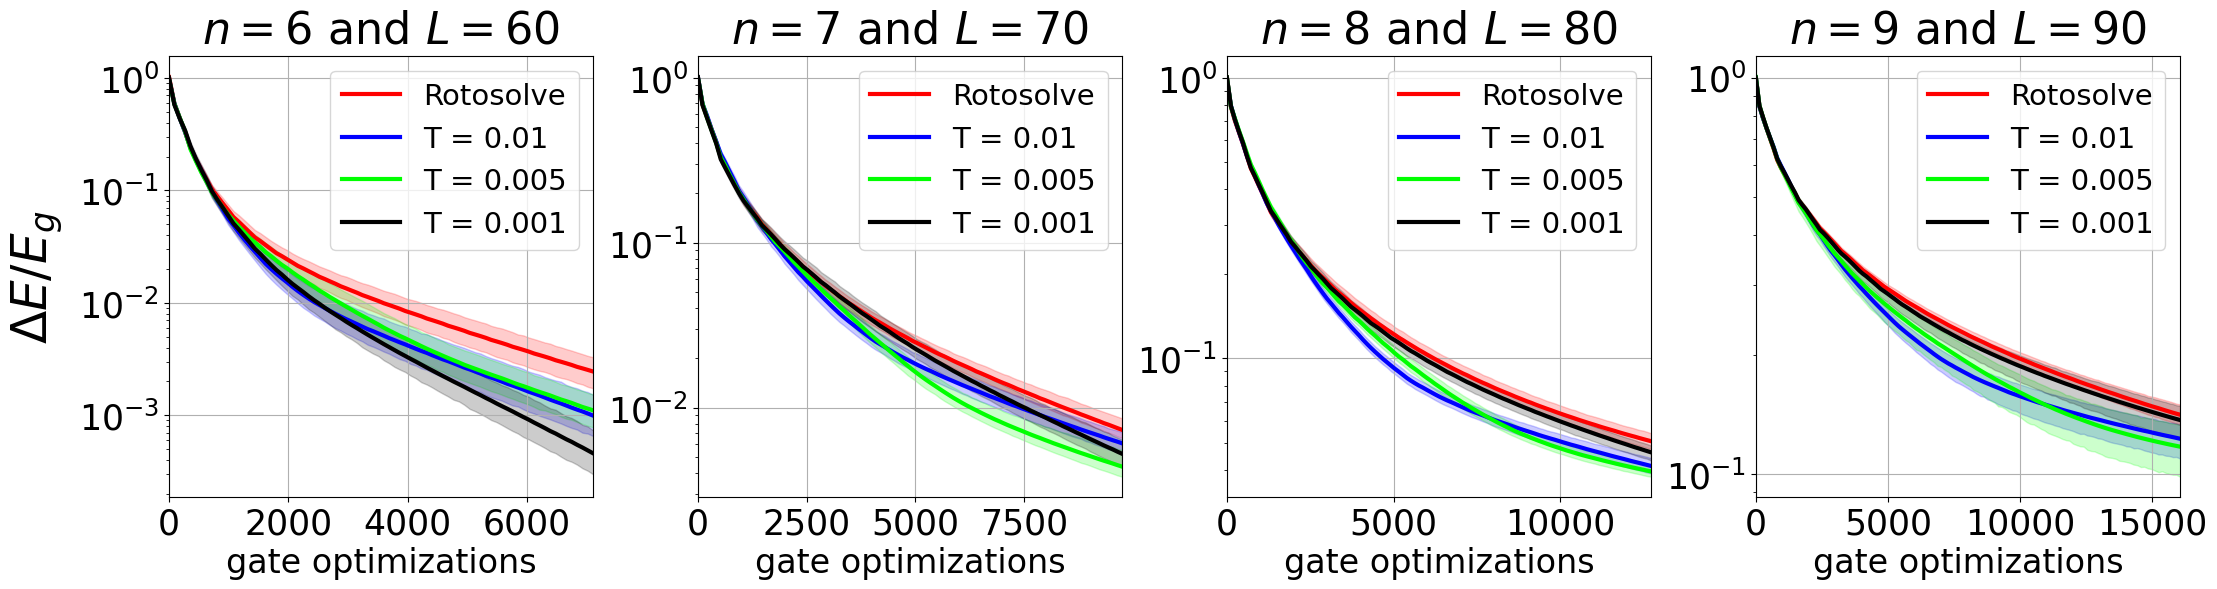

In [14]:
data_folder_L_10Q = f"../../data_folders/1DHeisenberg_Scalability_Rotosolve_L=10Q"


iters = 20
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.01, 0.005, 0.001]

qubits = [6,7,8,9]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(qubits))

fig.set_figheight(6)
fig.set_figwidth(22)

if len(qubits) == 1:
    axes = [axes]


for qubit, ax in zip(qubits, axes):
    layers = 10*qubit

    # take every k-th row for faster plotting
    every_n_row = 15*qubit

    df1 = pd.read_excel(f"{data_folder_L_10Q}/1DHeisenberg_{qubit}Q_rotosolve_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="Rotosolve")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.2, color="red")


    for d, color in zip(dvals, colors):
        df2 = pd.read_excel(f"{data_folder_L_10Q}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx") 
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)


        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.2, color=color)

       
    ax.set_title(f"$n={qubit}$ and $L={10*qubit}$", fontsize=32, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=24)
    
    ax.tick_params(labelsize=25)

    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")

    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize = 35, labelpad=10)
fig.tight_layout()

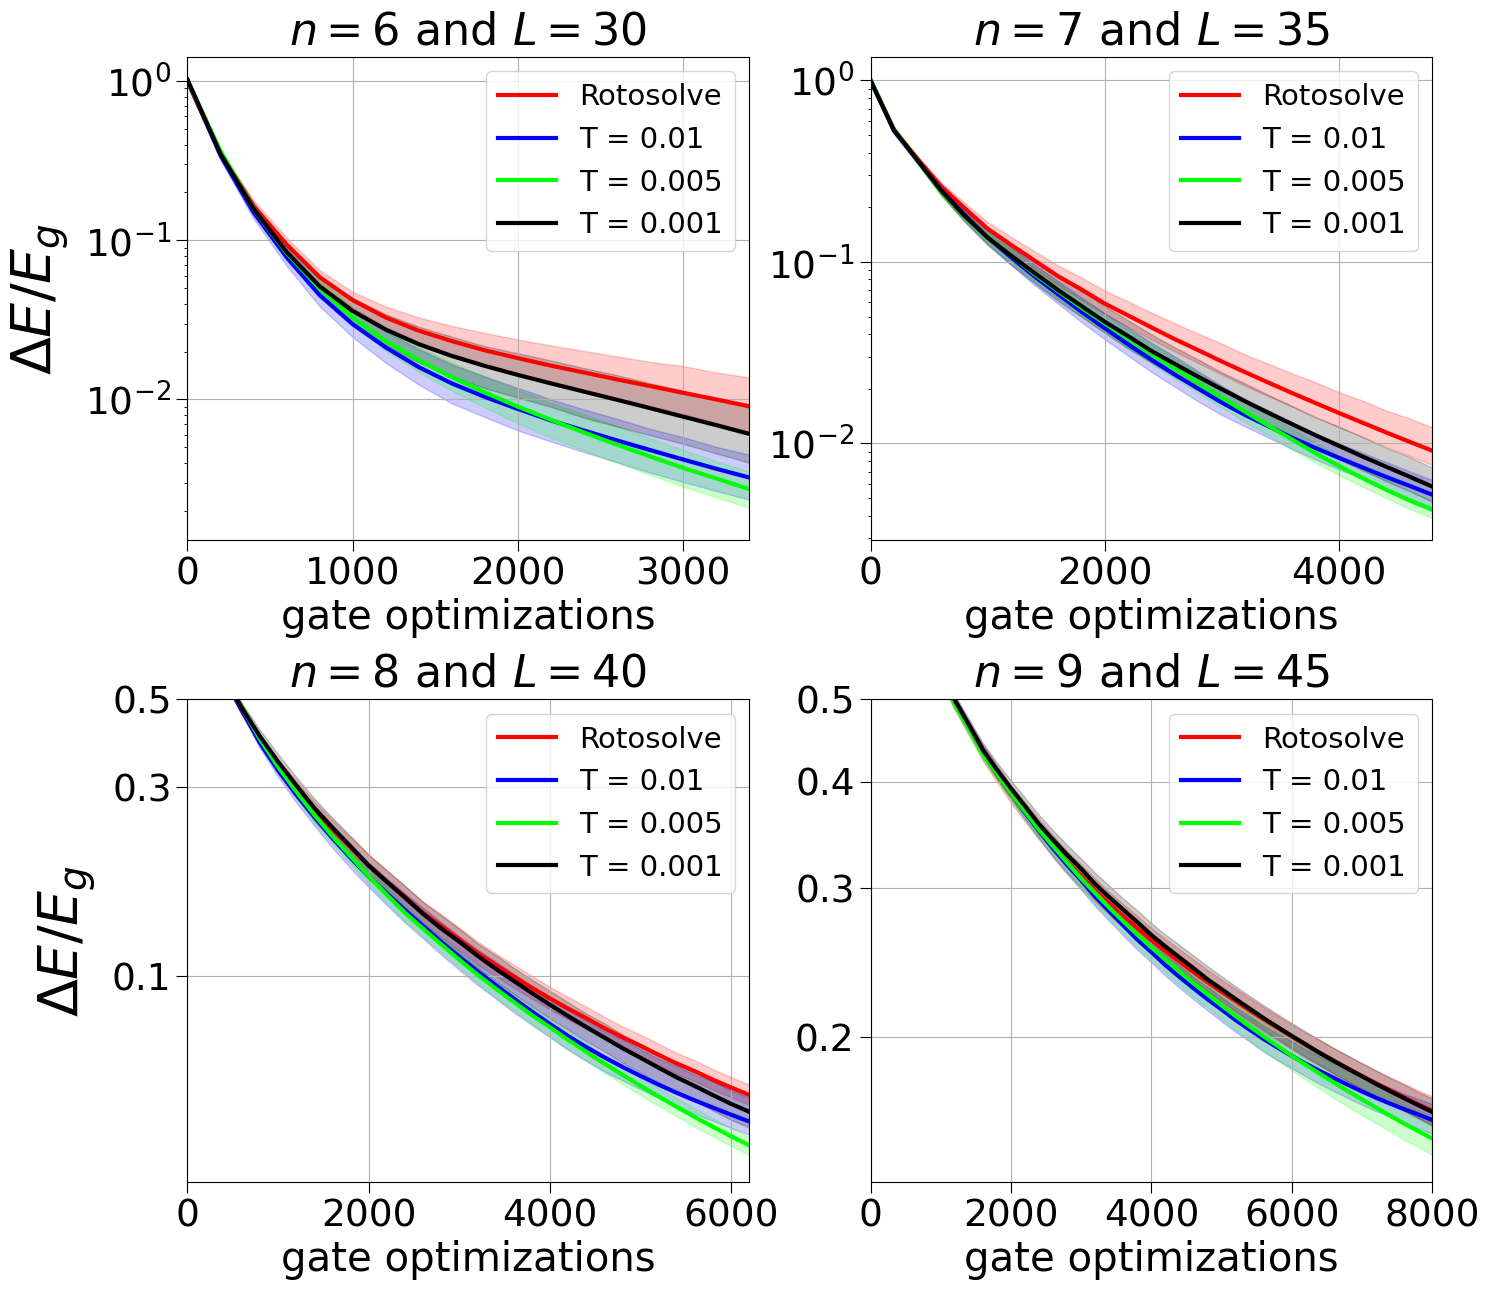

In [ ]:
data_folder_L_5Q = f"../../data_folders/1DHeisenberg_Scalability_Rotosolve_L=5Q"


qubit = 5
iters = 10
layers = 5*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.01, 0.005, 0.001]

qubits = [6,7,8,9]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(2, 2)

fig.set_figheight(13)
fig.set_figwidth(15)

if len(qubits) ==  1:
    axes = [axes]


# Take every k-th row for faster plotting
every_n_row = 200

i = 1

for qubit, ax in zip(qubits, axes.flatten()):
    layers = 5*qubit
    df1 = pd.read_excel(f"{data_folder_L_5Q}/1DHeisenberg_{qubit}Q_rotosolve_{iters}cycles_{layers}layers_{trials}trials_Evals_A.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="Rotosolve")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.2, color="red")


    for d, color in zip(dvals, colors):
        
        df2 = pd.read_excel(f"{data_folder_L_5Q}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx")
            
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)


        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.2, color=color)


    ax.set_title(f"$n={qubit}$ and $L={qubit*5}$", fontsize=32, y=1.01)
    ax.set_xlabel("gate optimizations", fontsize=29)
    ax.tick_params(labelsize=27, length=8)
    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")

    if qubit ==8:
        ax.set_yticks([0.5, 0.3, 0.1])
        ax.yaxis.set_major_formatter('{:.1f}'.format)
        ax.minorticks_off()

        ax.set_ylim(0.03, 0.5)

    if qubit == 9:
        ax.set_yticks([0.5, 0.4, 0.3, 0.2, 0.1])        
        ax.yaxis.set_major_formatter('{:.1f}'.format)
        ax.minorticks_off()
        ax.set_ylim(0.135, 0.5)


    ax.grid()
    ax.legend(fontsize=21)

    i+=1

axes[0][0].set_ylabel(r"$\Delta E / E_g$", fontsize = 40, labelpad=10)
axes[1][0].set_ylabel(r"$\Delta E / E_g$", fontsize = 40, labelpad=10)

fig.tight_layout()